# plot_results_single.ipynb

plot results from betacomp.ipynb

Set directories and parameters

In [1]:
### PATHS AND DIRECTORIES ###
# Location of .spec files
# p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"
results_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/betaout_p.txt"
# results_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/syn_betaout_p.txt"

# Location of earthquake catalog containing stress drop estimates
delsig_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_p.txt"
# delsig_catalog_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/syn_ds_p.txt"

# Location of spectra.pkl file/where to save it
paper_figure_dir = "/Users/ivandevert/Documents/papers/high_freq_ratio/paper_name_pre_submission/figs/"


### INPUT DATA PARAMETERS ###
phase = 'p' 
# phase = 's' 
units = ['h', 'n']
synthetic = False

# Beta computation params
stn_f_range = [2.5, 6.0]
dist_min = 0
dist_max = 100

### P-WAVE PARAMETERS ###
low_beta_window_p = [1, 5]
high_beta_window_p = [15, 22]
calib_mag_range_p = [1.4, 1.6]
# calib_mag_range_p = [1.0, 1.2]

### S-WAVE PARAMETERS ###
low_beta_window_s = [1, 5]
high_beta_window_s = [15, 22]
calib_mag_range_s = [1.9, 2.1]

# calibration event parameters
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10

# miscellaneous parameters
f_nyquist = 50.0
nf = 65

low_beta_window = [1, 5]
high_beta_window = [15, 22]


# process some of the parameters
units = [el.upper() for el in units]

# if phase == 'p':
#     components = ['Z']
#     calib_mag_range = calib_mag_range_p
#     low_beta_window = low_beta_window_p
#     high_beta_window = high_beta_window_p
#     spec_dir = p_spec_dir
# elif phase == 's':
#     components = ['N', 'E', '1', '2']

#     calib_mag_range = calib_mag_range_s
#     low_beta_window = low_beta_window_s
#     high_beta_window = high_beta_window_s
#     spec_dir = s_spec_dir

# xsec parameters
xsec_dmax = 1500

A =     [4.33E5, 3.974E6]
Ap =    [4.665E5, 3.938E6]
B =     [4.40E5, 3.9343E6]
Bp =    [4.60E5, 3.9543E6]


In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange


Define some functions

In [3]:

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

def get_sdir(stname):
    if stname[-1] in ['1', 'Z']:
        return 'V'
    elif stname[-1] in ['2', '3', 'N', 'E']:
        return 'H'
    else:
        raise ValueError(f"Unknown component: {stname[-1]}")
    

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out



In [10]:
# read in beta results
beta_cnames = ['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'dlogbeta', 'dlogbeta_corr']

df = pd.read_fwf(results_path, names=beta_cnames)
print(f"{len(df):,} events read from results_path")

# read in past results
if not synthetic:
    ds_cnames = ["event_id", "qyr", "qmon", "qday", "qhr", "qmn", "qsc", "qmag", 
            "qlat", "qlon", "qdep", "nst", "negf", "fc", "delsig"]
    ds_full = pd.read_fwf(delsig_catalog_path, names=ds_cnames)
    print(f"{len(ds_full):,} unique events with stress drop estimates from Vandevert et al. 2024")

elif synthetic:
    ds_cnames = ['event_id', 'delsig', 'fc', 'qlat', 'qlon', 'qmag']
    ds_full = pd.read_fwf(delsig_catalog_path, names=ds_cnames)
    print(f"{len(ds_full):,} unique events with synthetic stress drops")

    ds_full['delsig'] = ds_full['delsig'] / (1E6)
ds = ds_full[['event_id', 'delsig', 'fc']].copy()
df = pd.merge(df, ds, how='left', on='event_id')

# This fixes a bug where df doesn't groupby correctly when delsig is np.nan
df.loc[np.isnan(df['delsig']), 'delsig'] = 0
df.loc[np.isnan(df['fc']), 'fc'] = 0

df['easting'], df['northing'], zn, zl = utm.from_latlon(
    df['qlat'].values, 
    df['qlon'].values
    )
ds_full['easting'], ds_full['northing'], zn, zl = utm.from_latlon(
    ds_full['qlat'].values, 
    ds_full['qlon'].values
    )


11,266 events read from results_path
6,108 unique events with stress drop estimates from Vandevert et al. 2024


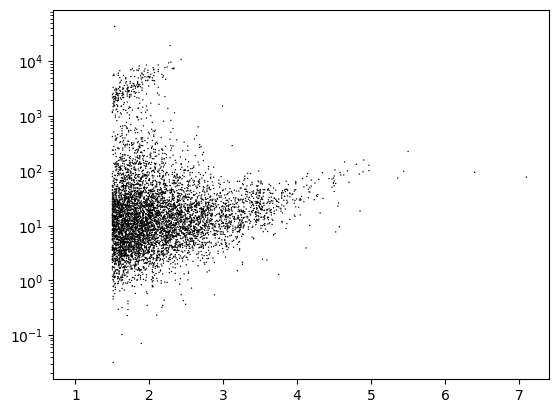

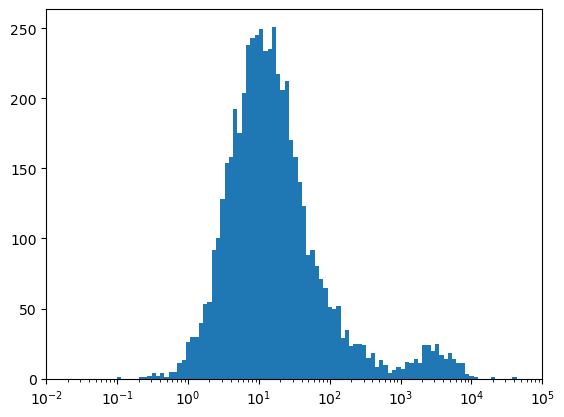

mean = 17.24 MPa
median = 13.36 MPa
std = 5.35 MPa


count     5443.000000
mean       198.646541
std       1041.807037
min          0.031740
25%          5.977500
50%         13.360000
75%         33.100000
max      43180.000000
Name: delsig, dtype: float64

In [28]:
plt.figure()
plt.scatter(df['qmag'], df['delsig'], c='k', s=1, edgecolors='none')
plt.yscale('log')
plt.show()


df_test = df[df['qmag'] <= 3.0]
df_test = df_test[df_test['delsig'] > 0]


# make logarithmic histogram of delsig
logedges = np.logspace(np.log10(1E-1), np.log10(1E5), 100)
plt.figure()
plt.hist(df_test['delsig'], bins=logedges)
ax = plt.gca()
ax.set_xscale('log')
ax.set_xlim((1E-2, 1E5))
plt.show()

logdelsig = np.log10(df_test['delsig'].values)


# print out mean, median, and standard deviation of delsig
print(f"mean = {10**np.mean(logdelsig):.2f} MPa")
print(f"median = {10**np.median(logdelsig):.2f} MPa")
print(f"std = {10**np.std(logdelsig):.2f} MPa")




df_test['delsig'].describe()





In [23]:
df_test['delsig']

51         44.800
73          7.009
81          0.000
83          0.000
84          0.000
           ...   
11261    1931.000
11262      31.570
11263      38.170
11264       0.000
11265      29.260
Name: delsig, Length: 10572, dtype: float64

In [22]:
sum(df_test['delsig']==0)

5129

In [ ]:
# Print out frequency information
f = np.linspace(0, f_nyquist, nf)
dfreq = f[1] - f[0]


# calculate actual indices and bands for beta computation
low_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window])
high_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window])

low_beta_band = [f[low_beta_window_inds[0]], f[low_beta_window_inds[1]]]
high_beta_band = [f[high_beta_window_inds[0]], f[high_beta_window_inds[1]]]


# calculate actual indices and bands for STN computations
stn_inds = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_band = [f[stn_inds[0]], f[stn_inds[1]]]


print("")
print("FREQUENCY ARRAY INFORMATION")
print("----------------------------")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print(f"Desired | Actual low-frequency band:   {low_beta_window[0]:7.3f} -{low_beta_window[1]:7.3f} Hz | {low_beta_band[0]:7.3f} -{low_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band:  {high_beta_window[0]:7.3f} -{high_beta_window[1]:7.3f} Hz | {high_beta_band[0]:7.3f} -{high_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_band[0]:7.3f} -{stn_band[1]:7.3f} Hz")


In [ ]:
# filtering arrays 
k = np.ones(len(df), dtype=bool)
k[np.isnan(df['dlogbeta'])] = False  # remove nan values
k[df['dlogbeta_corr']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr

clim = [-0.333, 0.333]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.linspace(clim[0], clim[1], 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = df[k]#[df['qmag']>2]
dataname = 'dlogbeta_corr'
datatitle = r"$\Delta\log\beta^*$"

# cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11.2, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})


mapout = mt.plot_map(
    df_plot,
    ax=ax[0],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

cb_ax = fig.add_axes([0.905,.5,.015,.37])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='neither')
smap.set_clim(clim)

cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



### OLD DELSIG DATA

clim = [1.5, 32.3]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = ds_full[~np.isnan(ds_full['delsig'])][ds_full['qmag']>2.0]
dataname = 'delsig'
datatitle = r"$\Delta\log\beta^*$"


mapout = mt.plot_map(
    df_plot,
    ax=ax[1],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)



cb_ax = fig.add_axes([0.905,.12,.015,.37])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='neither')
smap.set_clim(clim)
cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")

for AX in ax.flatten():
    AX.get_xaxis().set_ticks([])
    AX.get_yaxis().set_ticks([])


ax[0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=12)
ax[1].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=12)

# plt.savefig(f"{paper_figure_dir}map_comp.pdf", bbox_inches='tight')

plt.show()



In [ ]:

# dsylim = [1E-1, 1E4]
dsylim = [1E-1, 1E2]
xlim = [-0.5, 0.5]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6),
    layout='constrained')

ax.scatter(df['dlogbeta_corr'], df['delsig'], c=df['qmag'], s=3, marker='.', edgecolors='none')
ax.plot(xlim, xlim, c='k', linestyle='--')
ax.set_yscale('log')
ax.set_ylim(dsylim)
ax.set_xlim(xlim)
ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
ax.set_ylabel(r"P-wave $\Delta\sigma$ (MPa)")


# plt.savefig(f"{paper_figure_dir}value_comp.pdf", bbox_inches='tight')
plt.show()


# outliers

In [ ]:
df_outliers = df[df['delsig']>1000.0].reset_index(drop=True)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})


mapout = mt.plot_map(
    df_outliers,
    ax=ax,
    zoom=1.05,
    cname='delsig',
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

ax.scatter(df['easting'], df['northing'], c='k', s=1, marker='.', edgecolors='none')



In [ ]:
import stressdrop_file_IO as sdio
importlib.reload(sdio)

# proc_q = sdio.read_proc_q("/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/02_procspec/out.proc_q")[['event_id', 's1', 's2']]
kwargs = {
    "filepath": "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/10_pegfc/out.pegfcx.specfit",
    "header_names":['event_id', 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                    'qmag', 'qlat', 'qlon', 'qdep', 'nst', 'negf', 'sig0', 
                    'fc', 'fitrms', 'delsig', 'qmag_2', 'qmagpred', 
                    'qmag_mom', 'fmom', 'dsig1', 'dsig2', 'avalue', 'bvalue',
                    'nf', 'df', 'j1','j2','j3', 'j4','fmin','fmax','j5','j6'], 
    "data_names":["s1", "s2", "s3"], 
    "header_types":None, 
    "n_header_lines":2, 
    "delimiter":None
}


pegfcx = sdio.read_event_data_file_(**kwargs)

# pegfcx

In [ ]:
pegfcx['event_id'].values

In [ ]:
proc_q = proc_q[proc_q['event_id'].isin(df_outliers['event_id'])]

# merge columns s1 and s2 onto df_outliers
df_outliers = df_outliers.merge(proc_q, how='left', on='event_id')


In [ ]:

plt.figure()
plt.plot(f, df_outliers['s2'].values[6], c='k', linewidth=0.5)
plt.xscale('log')
plt.show()




In [ ]:

corrcoef = np.corrcoef(np.log10(df['delsig_p'][pp].values.astype(float)), df['dlogbeta_corr_p'][pp].values)[0,1]


txt = '\n'.join([
    f"correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure()
ax = plt.gca()
plt.scatter(df['qmag'], df['dlogbeta_corr_p'], c='k', s=3, marker='.', edgecolors='none')
plt.scatter(df['qmag'], df['dlogbeta_p'], c='r', s=3, marker='.', edgecolors='none')
plt.ylim([-0.8, 0.8])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel('Corrected logbeta')
plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/{phase}_logbeta_mag.pdf")
plt.show()

plt.figure()
ax = plt.gca()
plt.scatter(df['delsig_p'], df['dlogbeta_corr_p'], c=df['qmag'], s=3, marker='.')
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
plt.title("All corrected logbeta results")
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf")
plt.show()
plt.close()


# ds = df_target_ev[~np.isnan(df_target_ev['dlogbeta'])].reset_index(drop=True)
# ds['dlogbeta_corr'] = ds['dlogbeta'].values

# # indices where dlogbeta was calculated
# not_nan = ~np.isnan(ds['dlogbeta'])

# edges = np.arange(1, 7.3, 0.1)
# for i in range(len(edges)-1):
#     inrange = np.logical_and(ds['qmag']>=edges[i], ds['qmag']<edges[i+1])
#     keep = np.where(np.logical_and(inrange, not_nan))[0]
#     if np.sum(keep) > 0:
#         dlogbeta = ds['dlogbeta'].values[keep]
#         ds.loc[keep, 'dlogbeta_corr'] -= np.nanmedian(dlogbeta)


# # remove records with delsig==0
# ds = ds[ds['delsig'] != 0].reset_index(drop=True)

# corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]


# txt = '\n'.join([
#     f"correlation: {corrcoef:.4f}", 
#     f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
#     f"Calib. dmax: {calib_rmax:.1f} km",
#     f"Calib. zmax: {calib_zmax:.1f} km",
#     f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
#     f"n calib. minimum: {ncalib_min}",
#     f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
#     f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
# ])

# plt.figure()
# ax = plt.gca()
# plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
# plt.xscale('log')
# plt.ylim([-0.8, 0.8])
# plt.xlim([0.5, 5000.0])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
# plt.xlabel('Stress drop (MPa)')
# plt.ylabel('Corrected logbeta')
# # plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
# plt.show()
# plt.close()


In [ ]:
# Depth variation

dx = 0.2
edges = np.arange(0, 20, 0.5)

fig, ax = plt.subplots(1,2,figsize=(7,4), sharex=True, sharey=True, layout='constrained')
ax[0].scatter(df['qdep'][pp], df['dlogbeta_corr_p'][pp], c='k', s=3, marker='.', edgecolors='none')
ax[1].scatter(df['qdep'][ss], df['dlogbeta_corr_s'][ss], c='k', s=3, marker='.', edgecolors='none')
boxplot(df['qdep'][pp], df['dlogbeta_corr_p'][pp], xbins=edges, ax=ax[0], color='r')
boxplot(df['qdep'][ss], df['dlogbeta_corr_s'][ss], xbins=edges, ax=ax[1], color='r')
ax[0].set_ylim([-1, 1])
ax[0].set_xlim([0, 12])
ax[0].set_xlabel('Earthquake depth (km)')
ax[0].set_ylabel(r'$\Delta\log\beta^*$')
ax[0].axhline(0, c='k', linestyle='--')
ax[1].axhline(0, c='k', linestyle='--')
# plt.savefig(f"figs/dlogbeta_dep_{phase}.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# dx = 0.2
# edges = np.arange(1.0, 7.3, dx)


# fig, axs = plt.subplots(1,2, figsize=(8,4), layout='constrained', sharex=True)

# axs[0].scatter(ds['qmag'], ds['fc'], c='k', s=1, edgecolors='none')
# axs[1].scatter(ds['qmag'], ds['delsig'], c='k', s=1, edgecolors='none')

# boxplot(ds['qmag'], ds['fc'], xbins=edges, ax=axs[0], color='r')
# boxplot(ds['qmag'], ds['delsig'], xbins=edges, ax=axs[1], color='r')

# axs[0].set_yscale('log')
# axs[1].set_yscale('log')

# axs[0].set_ylabel('Corner frequency (Hz)')
# axs[1].set_ylabel('Stress drop (MPa)')

# axs[0].set_xlim([0.8,5.1])
# axs[0].set_ylim([1E-1, 1E3])

# axs[1].set_ylim([1E-1, 1E2])

# # plt.savefig(paper_figure_dir + "syn_source_params.pdf", bbox_inches='tight')
# plt.show()

In [ ]:
np.log10(ds['delsig']).describe()

In [ ]:
# df_plot['qmag'].describe()

In [ ]:
# for i in range(df_['stind'].max()):
#     nsta = len(df_[df_['stind']==i])
#     print(f'{nsta} in {i}')

In [ ]:
# dependents = ['deldist', 's1', 's2', 'logbeta']
# st_dep = ['stname', 'slat', 'slon', 'selev', 'sx', 'sy', 'stind']

In [ ]:
dependents


In [ ]:
corrcoef = np.corrcoef(np.log10(ds['fc'].values.astype(float)), ds['dlogbeta'].values)[0,1]


txt = '\n'.join([
    f"Correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure(figsize=(5,5))
ax = plt.gca()
sc = plt.scatter(ds['fc'], ds['dlogbeta'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
plt.xscale('log')
# plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 200.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Corner frequency (Hz)')
plt.ylabel(r'$\Delta\log\beta$')
fig = sc.figure
cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
ax.axvline(low_beta_band[0], ls='--', c='k')
ax.axvline(low_beta_band[1], ls='--', c='k')
ax.axvline(high_beta_band[0], ls='--', c='k')
ax.axvline(high_beta_band[1], ls='--', c='k')
# plt.savefig(f"figs/{phase}_fc_correlation.pdf", bbox_inches='tight')
plt.savefig(paper_figure_dir + f"{phase}_fc_correlation.pdf", bbox_inches='tight')
plt.show()








# corrcoef = np.corrcoef(np.log10(ds['m0'].values.astype(float)), ds['dlogbeta'].values)[0,1]


# txt = '\n'.join([
#     f"Correlation: {corrcoef:.4f}", 
#     f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
#     f"Calib. dmax: {calib_rmax:.1f} km",
#     f"Calib. zmax: {calib_zmax:.1f} km",
#     f"n calib. minimum: {ncalib_min}",
#     f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
#     f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
# ])

# plt.figure()
# ax = plt.gca()
# sc = plt.scatter(ds['m0'], ds['dlogbeta'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
# plt.xscale('log')
# # plt.ylim([-0.8, 0.8])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
# plt.xlabel('Seismic Moment')
# plt.ylabel(r'$\Delta\log\beta$')
# fig = sc.figure
# cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
# fig.colorbar(sc, cax=cax)
# cax.set_ylabel('Magnitude')
# plt.savefig(f"figs/{phase}m0_correlation.pdf")
# plt.show()







corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]

txt = '\n'.join([
    f"Correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure(figsize=(5,5))
ax = plt.gca()
sc = plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("All corrected logbeta results")
# colorbar, Magnitude
fig = sc.figure
cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf", bbox_inches='tight')
plt.savefig(paper_figure_dir + f"{phase}_delsig_correlation.pdf", bbox_inches='tight')
plt.show()


In [ ]:
dx = 0.2
edges = np.arange(1.0, 7.3, dx)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta'], c='r', s=3, marker='.', edgecolors='none')
boxplot(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
plt.xlim([1.0, 5.0])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/dlogbeta_corr.pdf", bbox_inches='tight')
plt.show()


In [ ]:
dx = 0.2
edges = np.arange(0, 20, 0.5)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
plt.scatter(df_target_ev['qdep'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta'], c='r', s=3, marker='.', edgecolors='none')
boxplot(df_target_ev['qdep'], df_target_ev['dlogbeta_corr'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
plt.xlim([0, 12])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Earthquake depth (km)')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/dlogbeta_dep.pdf", bbox_inches='tight')
plt.show()

In [ ]:
df

In [ ]:
scatter_kwargs = {'s':1, 'marker':'.', 'edgecolors':'none'}

dx = 0.2
edges = np.arange(1.0, 7.3, dx)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
# ax.scatter(df['qmag'], df['logbeta'], c='k', s=3, marker='.', edgecolors='none')
# plt.boxplot(df['logbeta'].values, widths=0.5, sym='.', whis=(5, 95))
ax.scatter(df['qmag'], df['dlogbeta_p'], color='gray', **scatter_kwargs)
boxplot(df['qmag'], df['dlogbeta_p'], xbins=edges, ax=ax, color='r')
plt.xlim([1.0, 5.0])
plt.ylim([-2,2])
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\log\beta$')
# plt.savefig(f"figs/all_logbeta.png", bbox_inches='tight', dpi=600)
plt.show()


In [ ]:
plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
plt.scatter(df['qmag'], df['dlogbeta_p'], c='k', s=3, marker='.', edgecolors='none')
boxplot(df['qmag'], df['dlogbeta_p'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\Delta\log\beta$')
plt.xlim([1.0, 5.0])
# plt.savefig(f"figs/event_dlogbeta.pdf", bbox_inches='tight')
plt.show()

In [ ]:
df_plot['qmag'].describe()